In [1]:
# load dependencies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [11]:
# load data
df = pd.read_csv("./data/changauto4225.csv")

# --- Convert time1 and time2 to datetime objects ---
df['time1'] = pd.to_datetime(df['time1'], format='%d%b%Y', errors='coerce')
df['time2'] = pd.to_datetime(df['time2'], format='%d%b%Y', errors='coerce')

# Handle potential NaT values after date conversion (important!)
df.dropna(subset=['time1', 'time2'], inplace=True)

df

,patid,time1,time2,earliest_af_date,earliest_stroke_date,end_fu,end_fu_due_to_death,stroke_1Y,stroke_time,Anticoagulant,...,HB_stroke_history,ckd,ethnic_group,frailty_score,bmi,tc_mmol_L,acr_mg_mmol,smoking_status,vasc_dis_mi_pad,aortic_plaq
0,1145,2008-12-21,2009-03-20,21dec2008,NaN,25jan2010,1,2,NaN,No anticoagulant,...,0,0,White,0.111111,NaN,NaN,NaN,Ex-smoker,0,0
1,1148,2009-03-18,2009-06-15,18mar2009,NaN,04feb2010,0,2,NaN,No anticoagulant,...,0,1,White,0.250000,26.42068,5.2,NaN,Ex-smoker,1,0
2,1272,2010-07-08,2010-10-05,08jul2010,NaN,30sep2016,0,2,NaN,No anticoagulant,...,0,0,White,0.083333,30.14280,4.9,NaN,Non-smoker,0,0
3,1385,2004-10-13,2005-01-10,13oct2004,NaN,04sep2009,0,2,NaN,No anticoagulant,...,0,0,White,0.111111,26.46263,3.4,NaN,Ex-smoker,0,0
4,1394,2011-09-06,2011-12-04,06sep2011,NaN,09aug2015,0,2,NaN,No anticoagulant,...,0,0,White,0.111111,30.65273,4.1,NaN,Ex-smoker,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128585,93825229,2018-06-19,2018-09-16,19jun2018,NaN,30nov2018,0,2,NaN,No anticoagulant,...,0,0,White,0.083333,31.32211,6.0,NaN,Non-smoker,0,0
128586,94578229,2016-12-23,2017-01-17,23dec2016,NaN,30nov2018,0,2,NaN,No anticoagulant,...,0,1,White,0.222222,28.02293,6.3,NaN,Non-smoker,0,0
128587,95799229,2018-01-08,2018-01-20,08jan2018,08jan2018,20jan2018,1,1,0.0,No anticoagulant,...,1,0,Pakistani,0.194444,20.82094,3.5,NaN,Ex-smoker,0,0
128588,96029229,2018-07-02,2018-09-29,02jul2018,NaN,30nov2018,0,2,NaN,No anticoagulant,...,0,0,White,0.055556,31.34694,5.8,NaN,Non-smoker,0,0


In [7]:
df.columns

Index(['patid', 'time1', 'time2', 'earliest_af_date', 'earliest_stroke_date',
       'end_fu', 'end_fu_due_to_death', 'stroke_1Y', 'stroke_time',
       'Anticoagulant', 'age', 'age_at_entry', 'gender', 'af', 'hypertension',
       'diab', 'thrombo', 'hf', 'HB_stroke_history', 'ckd', 'ethnic_group',
       'frailty_score', 'bmi', 'tc_mmol_L', 'acr_mg_mmol', 'smoking_status',
       'vasc_dis_mi_pad', 'aortic_plaq'],
      dtype='object')

In [6]:
# Columns to exclude from shuffling
exclude_cols = ['time1', 'time2', 'earliest_af_date', 'earliest_stroke_date',
                'end_fu', 'end_fu_due_to_death', 'stroke_1Y', 'stroke_time', 'af']

# Get a list of columns to shuffle
shuffle_cols = [col for col in df.columns if col not in exclude_cols and col!= 'patid']

# Shuffle the data in each column
for col in shuffle_cols:
    df[col] = np.random.permutation(df[col].values)

# Remove the 'patid' column
df_anon = df.drop('patid', axis=1)

In [8]:
df_anon.to_csv('./data/cprd_dummy.csv', index=False)

In [6]:
for col in ['time1', 'time2', 'earliest_af_date', 'earliest_stroke_date', 'end_fu']:
    df[col] = pd.to_datetime(df[col], format='%d-%b-%y', errors='coerce')

# Display the converted dates
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

| patid   | time1               | time2               | earliest_af_date    | earliest_stroke_date   | end_fu              | end_fu_due_to_death   | stroke_1Y   | stroke_time   | Anticoagulant    | age   | gender (1=male)   | af   | hypertension   | diab   | thrombo   | Heart failure   | Prior stroke   | ckd   | ethnic_group   | frailty_score   | bmi     | tc_mmol_L   | acr_mg_mmol   | smoking_status   | vasc_dis_mi_pad   | aortic_plaq   |
|:--------|:--------------------|:--------------------|:--------------------|:-----------------------|:--------------------|:----------------------|:------------|:--------------|:-----------------|:------|:------------------|:-----|:---------------|:-------|:----------|:----------------|:---------------|:------|:---------------|:----------------|:--------|:------------|:--------------|:-----------------|:------------------|:--------------|
| 1145    | 2008-12-21 00:00:00 | 2009-03-20 00:00:00 | 2008-12-21 00:00:00 | NaT                    | 2010-01-2

In [14]:
print(df.info())


# explore time from AF diagnosis to stroke, but no anticoagulation date
- 90-day window after AF diagnosis with most recent prescription of anticoagulant
- AF stroke concomitant - exclude because of issue of haemorrhagic conversion ???
- perhaps only look at patients who have stroke > x days after AF diagnosis
- exclusion of concomitant diagnosis up to 7 days apart, 14 days apart, sensitivity analyses ?

- paper from Nick, DOAC v warfarin v no treatment CHADSVASC=1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128590 entries, 0 to 128589
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   patid                 128590 non-null  int64         
 1   time1                 128590 non-null  datetime64[ns]
 2   time2                 128590 non-null  datetime64[ns]
 3   earliest_af_date      128590 non-null  datetime64[ns]
 4   earliest_stroke_date  15976 non-null   datetime64[ns]
 5   end_fu                128590 non-null  datetime64[ns]
 6   end_fu_due_to_death   128590 non-null  int64         
 7   stroke_1Y             10401 non-null   float64       
 8   stroke_time           15976 non-null   float64       
 9   Anticoagulant         128590 non-null  object        
 10  age                   128590 non-null  int64         
 11  gender (1=male)       128590 non-null  int64         
 12  af                    128590 non-null  int64         
 13 

In [15]:
# --- Descriptive Statistics ---
# For numerical variables
print(df.describe().to_markdown(numalign="left", stralign="left"))

|       | patid       | end_fu_due_to_death   | stroke_1Y   | stroke_time   | age     | gender (1=male)   | af     | hypertension   | diab     | thrombo   | Heart failure   | Prior stroke   | ckd      | frailty_score   | bmi     | tc_mmol_L   | acr_mg_mmol   | vasc_dis_mi_pad   | aortic_plaq   |
|:------|:------------|:----------------------|:------------|:--------------|:--------|:------------------|:-------|:---------------|:---------|:----------|:----------------|:---------------|:---------|:----------------|:--------|:------------|:--------------|:------------------|:--------------|
| count | 128590      | 128590                | 10401       | 15976         | 128590  | 128590            | 128590 | 128590         | 128590   | 128590    | 128590          | 128590         | 128590   | 128590          | 111107  | 94342       | 12582         | 128590            | 128590        |
| mean  | 1.01186e+07 | 0.410327              | 2           | 2.06135       | 75.7149 | 1.49214           | 1

In [16]:
# For categorical variables
print(df.describe(include=['object']).to_markdown(numalign="left", stralign="left"))

|        | Anticoagulant    | ethnic_group   | smoking_status   |
|:-------|:-----------------|:---------------|:-----------------|
| count  | 128590           | 128590         | 123470           |
| unique | 3                | 12             | 3                |
| top    | No anticoagulant | White          | Ex-smoker        |
| freq   | 117719           | 119434         | 55575            |


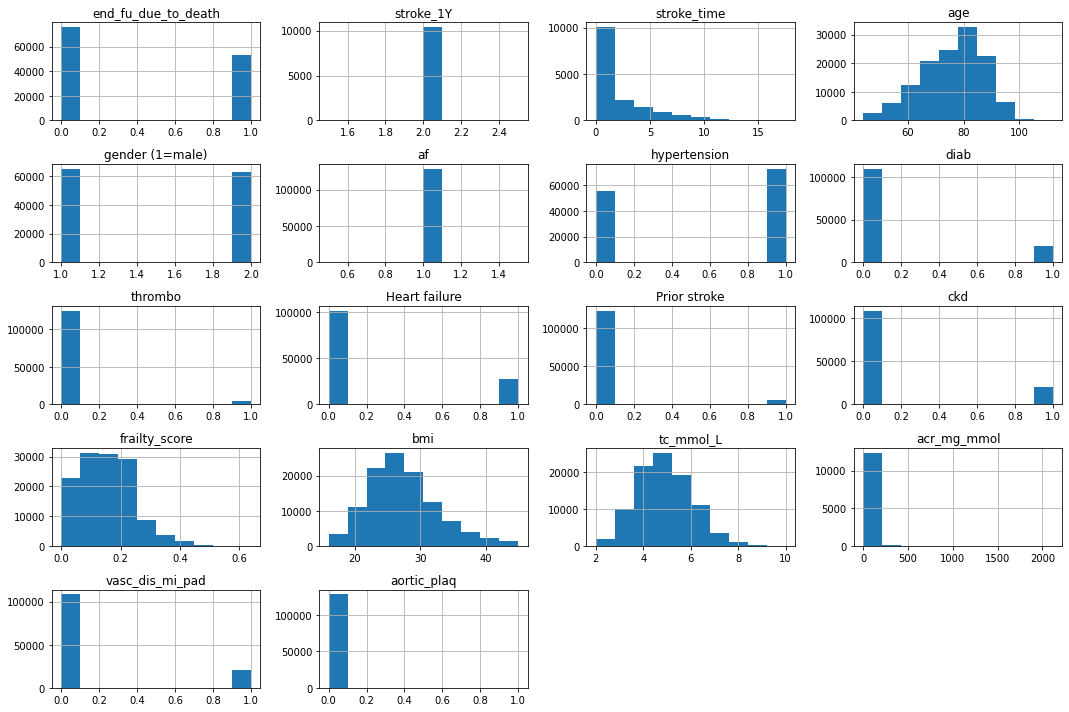

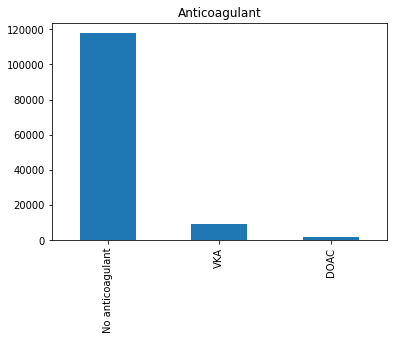

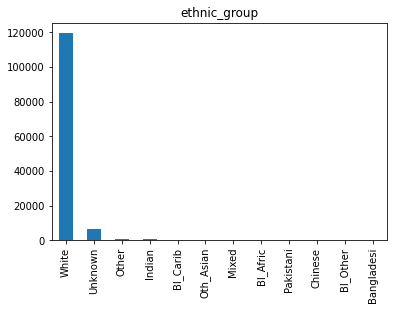

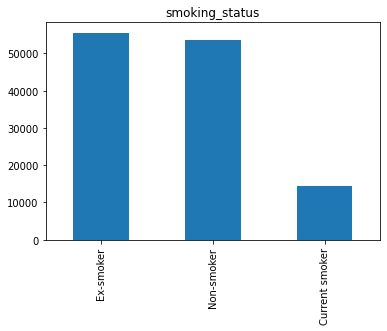

In [17]:
# --- Univariate Analysis ---

# Separate numerical and categorical columns (excluding 'patid')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('patid')
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Histograms for numerical variables
df[numerical_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

# Bar plots for categorical variables
for col in categorical_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

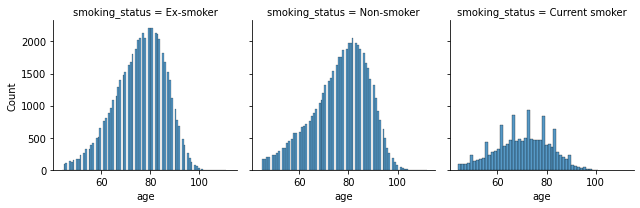

In [20]:
# --- Facet Plots ---

# Example FacetGrid for numerical variables
g = sns.FacetGrid(df, col='smoking_status')
g.map(sns.histplot, 'age')
plt.show()


In [28]:
df['stroke_time'].value_counts()

0.000000     5213
0.002738       62
0.005476       56
0.010951       46
0.019165       44
             ... 
15.427790       1
9.097878        1
2.469541        1
5.119781        1
5.601643        1
Name: stroke_time, Length: 3288, dtype: int64

In [31]:
# Filter rows where 'stroke_time' is less than 10
filtered_df = df[df['stroke_time'] < 10]

# Display the filtered dataframe
filtered_df

,patid,time1,time2,earliest_af_date,earliest_stroke_date,end_fu,end_fu_due_to_death,stroke_1Y,stroke_time,Anticoagulant,...,Prior stroke,ckd,ethnic_group,frailty_score,bmi,tc_mmol_L,acr_mg_mmol,smoking_status,vasc_dis_mi_pad,aortic_plaq
11,2257,07-Apr-04,29-May-04,07-Apr-04,07-Apr-04,29-May-04,1,2.0,0.000000,No anticoagulant,...,0,0,White,0.222222,24.09297,5.5,NaN,Ex-smoker,1,0
45,5541,31-Jul-02,28-Oct-02,31-Jul-02,30-Apr-07,01-May-15,1,NaN,4.747433,No anticoagulant,...,0,0,White,0.083333,20.79673,NaN,NaN,Ex-smoker,0,0
60,7251,12-Oct-17,09-Jan-18,12-Oct-17,12-Oct-17,30-Nov-18,0,2.0,0.000000,No anticoagulant,...,0,0,White,0.305556,20.06920,5.8,NaN,Current smoker,0,0
68,8294,05-Sep-10,03-Dec-10,05-Sep-10,05-Sep-10,20-Oct-12,1,2.0,0.000000,No anticoagulant,...,1,1,White,0.222222,21.67126,3.1,25.0,Ex-smoker,1,0
70,8573,10-May-14,19-Jul-14,10-May-14,10-May-14,19-Jul-14,1,2.0,0.000000,No anticoagulant,...,0,1,White,0.222222,28.91499,3.4,1.4,Non-smoker,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128526,75924229,22-Feb-15,22-May-15,22-Feb-15,01-Aug-15,24-Aug-15,1,2.0,0.438056,No anticoagulant,...,0,0,White,0.277778,31.05216,6.4,NaN,Ex-smoker,0,0
128569,87284229,18-Nov-17,15-Feb-18,18-Nov-17,18-Nov-17,30-Nov-18,0,2.0,0.000000,No anticoagulant,...,1,0,White,0.027778,23.42980,NaN,NaN,Current smoker,0,0
128570,87482229,15-Mar-16,12-Jun-16,15-Mar-16,15-Mar-16,21-Jan-17,1,2.0,0.000000,No anticoagulant,...,1,0,White,0.277778,22.77898,4.2,NaN,Ex-smoker,0,0
128577,89889229,09-Apr-16,12-Apr-16,09-Apr-16,09-Apr-16,12-Apr-16,1,2.0,0.000000,No anticoagulant,...,1,0,White,0.166667,30.79001,3.7,NaN,Ex-smoker,0,0


## Validating CHADS-VASc

In [17]:
def calculate_chadsvasc(row):
    """Calculates the CHADS-VASc score for a single patient (row of a DataFrame)."""
    score = 0
    # Congestive heart failure
    score += int(row['hf'])
    # Hypertension
    score += int(row['hypertension'])
    # Age >= 75
    score += 2 * int(row['age'] >= 75)
    score += int(65 <= row['age'] < 75)
    # Diabetes mellitus
    score += int(row['diab'])
    # Stroke/TIA/Thromboembolism
    score += 2 * int(row['thrombo'] or row['HB_stroke_history'])
    # Vascular disease
    score += int(row['vasc_dis_mi_pad'])
    # Sex (Female)
    score += int(row['gender'] != 1)
    return score

def calculate_stroke_rate(group, total_patients, total_years, event_col='stroke_1y'):
    """Calculates the adjusted stroke rate per 100 patient-years."""
    if total_patients == 0 or pd.isna(total_years):  # Handle potential NaNs
        return 0

    num_strokes = group[event_col].sum()
    return (num_strokes / total_years) * 100

def confidence_interval(rate, total_years):
    """Calculates the 95% confidence interval for the stroke rate."""
    if rate == 0 or total_years == 0 or pd.isna(total_years): # Handle potential NaNs
        return (0, 0)

    z = 1.96  # For 95% CI
    lambda_val = (rate / 100) * total_years
    lower_bound = stats.poisson.ppf(0.025, lambda_val) / total_years * 100
    upper_bound = stats.poisson.ppf(0.975, lambda_val) / total_years * 100
    return (lower_bound, upper_bound)

def validate_chadsvasc(df, time1_col, time2_col, stroke_event_col='stroke_1y'):
    """
    Validates the CHADS-VASc score, handling datetime conversion.
    """
    df['CHADS-Vasc'] = df.apply(calculate_chadsvasc, axis=1)
    # Calculate follow-up time in years
    df['Follow_Up_Years'] = (df[time2_col] - df[time1_col]) / np.timedelta64(1, 'Y')

    grouped = df.groupby('CHADS-Vasc')
    results = []
    for score, group in grouped:
        total_patients = len(group)
        total_years = group['Follow_Up_Years'].sum()
        observed_rate = calculate_stroke_rate(group, total_patients, total_years, event_col=stroke_event_col)
        ci = confidence_interval(observed_rate, total_years)
        results.append({
            'CHADS-Vasc': score,
            'Number of Patients': total_patients,
            'Total Patient Years': total_years,
            'Observed Stroke Rate': observed_rate,
            '95% CI Lower': ci[0],
            '95% CI Upper': ci[1],
        })

    results_df = pd.DataFrame(results)
    original_rates = {
        0: 0.0, 1: 1.3, 2: 2.2, 3: 3.2, 4: 4.0,
        5: 6.7, 6: 9.8, 7: 9.6, 8: 6.7, 9: 15.2
    }
    original_rates_ci_lower = {score: np.nan for score in original_rates}
    original_rates_ci_upper = {score: np.nan for score in original_rates}

    results_df['Original Stroke Rate'] = results_df['CHADS-Vasc'].map(original_rates)
    results_df['Original CI Lower'] = results_df['CHADS-Vasc'].map(original_rates_ci_lower)
    results_df['Original CI Upper'] = results_df['CHADS-Vasc'].map(original_rates_ci_upper)

    results_df['Original Rate Within CI'] = (
        (results_df['Original Stroke Rate'] >= results_df['95% CI Lower']) &
        (results_df['Original Stroke Rate'] <= results_df['95% CI Upper'])
    )

    results_df = results_df[['CHADS-Vasc', 'Number of Patients', 'Total Patient Years',
                            'Observed Stroke Rate', '95% CI Lower', '95% CI Upper',
                            'Original Stroke Rate', 'Original CI Lower', 'Original CI Upper',
                            'Original Rate Within CI']]
    return results_df

In [18]:
#run validation

validation_results = validate_chadsvasc(df.copy(), 'time1', 'time2', 'stroke_1y') 

# print results
print(validation_results.to_string())


KeyError: 'stroke_1y'